# 07 - Institution Ranking

## Objective
- Create affiliation-level policy-cited paper rankings
- Generate LaTeX table outputs (Table S2: Top 200 affiliations)
- Compare citation counts with similar papers using KNN neighbor search

## Inputs
- `tmp/policy_cited_paper.pickle`: Policy-cited paper data
- `tmp/partition_info.pickle`: Cluster information
- Scopus: af_name2, af_country, embedding, num_cited, year, title

## Outputs
- `output/table_affiliation_top100.tex`: Top 100 affiliations LaTeX table
- `output/table_affiliation_100_200.tex`: Rank 101-200 affiliations LaTeX table
- `output/fig_country_top200.eps`: Country distribution of top 200 affiliations

In [ ]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import glob
import collections
import textwrap
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
from scipy import stats
from sklearn.neighbors import NearestNeighbors

from config.settings import TmpPaths, OutputPaths, SCOPUS_BASE, POLICY_CITE_BASE
from src.utils import flatten2, gini

%matplotlib inline
%config InlineBackend.figure_format='retina'
plt.style.use(['science', 'no-latex'])
warnings.filterwarnings('ignore')

In [3]:

policy_cited_scopus = pd.read_pickle(TmpPaths.POLICY_CITED_PAPER)
partition_info = pd.read_pickle(TmpPaths.PARTITION_INFO)
year_cited = pd.read_pickle(f'{POLICY_CITE_BASE}/year_cited.pickle')

for y in range(2017, 2025):
    policy_cited_scopus[f'year_cited_{y}'] = policy_cited_scopus.doi.map(year_cited[y])

print(f"Policy cited papers: {len(policy_cited_scopus):,}")
print(f"Year range: {policy_cited_scopus.year.min()} - {policy_cited_scopus.year.max()}")

Policy cited papers: 230,737
Year range: 2015 - 2023


In [4]:

af_name = pd.read_pickle(f'{SCOPUS_BASE}/affiliation/af_name2.pickle')
af_country = pd.read_pickle(f'{SCOPUS_BASE}/affiliation/af_country.pickle')
num_cited = pd.read_pickle(f'{SCOPUS_BASE}/paper/num_cited.pickle')
journal_name = pd.read_pickle(f'{SCOPUS_BASE}/journal/journal_name.pickle')

print(f"Affiliations: {len(af_name):,}")

Affiliations: 4,644,957


---
# Affiliation-Level Ranking

In [5]:

af_count = pd.DataFrame(
    flatten2(policy_cited_scopus.afids.apply(lambda x: [[y, 1/len(x)] for y in x]))
)
af_count = af_count.groupby(0).sum()[1]

af_count_f = pd.DataFrame(
    flatten2(policy_cited_scopus.afids.apply(lambda x: [[y, 1] for y in x[:1]]))
)
af_count_f = af_count_f.groupby(0).sum()[1]

policy_cited_scopus['afid_first'] = policy_cited_scopus.afids.dropna().apply(
    lambda x: x[0] if len(x) > 0 else None
)

af_paper = policy_cited_scopus.dropna(subset=['afid_first']).groupby('afid_first').eid.agg(list)

print(f"Unique affiliations (first author): {len(af_count_f):,}")

Unique affiliations (first author): 28,677


In [6]:

count_af = pd.concat([af_name, af_country, af_count_f, af_paper], axis=1).dropna()
count_af.columns = ['name', 'country', 1, 'eid']
count_af = count_af.sort_values(1, ascending=False)

count_af['num_paper'] = count_af[1].apply(int)
count_af['country'] = count_af['country'].apply(lambda x: x.upper())
count_af['rank'] = np.arange(len(count_af)) + 1

print(f"Top 10 affiliations:")
print(count_af[['name', 'country', 'num_paper']].head(10))

Top 10 affiliations:
                                                         name country  \
60004156.0                          Wageningen University_nld     NLD   
60031331.0  London School of Hygiene and Tropical Medicine...     GBR   
60022148.0                      University College London_gbr     GBR   
60026851.0                           University of Oxford_gbr     GBR   
60031004.0                       University of Queensland_aus     AUS   
60112834.0                                     World Bank_usa     USA   
60003059.0                     London School of Economics_gbr     GBR   
60027142.0                      World Health Organization_che     CHE   
60010365.0                 University of British Columbia_can     CAN   
60015150.0                        Imperial College London_gbr     GBR   

            num_paper  
60004156.0       1095  
60031331.0        994  
60022148.0        885  
60026851.0        878  
60031004.0        839  
60112834.0        837  
6000305

In [7]:

count_af_ = pd.concat([
    count_af.groupby('name').sum()[1],
    count_af.groupby('name').country.agg(lambda x: pd.Series.mode(x)[0]),
    count_af.groupby('name').eid.agg(flatten2)
], axis=1)
count_af_ = count_af_.sort_values(1, ascending=False)
count_af_['rank'] = list(range(1, len(count_af_) + 1))
count_af_.columns = ['IGO policy cited papers', 'country', 'eids', 'rank']
count_af_['IGO policy cited papers'] = count_af_['IGO policy cited papers'].apply(int)
count_af_.index = [i.split('_')[0] for i in count_af_.index]

print(f"Unique institutions (aggregated): {len(count_af_):,}")

Unique institutions (aggregated): 22,362


In [8]:
count_af_['name'] = count_af_.index
count_af_['num_paper'] = count_af_['IGO policy cited papers']

---
# LaTeX Table Generation

In [9]:

def break_two_lines(s, width=30):
    lines = textwrap.wrap(s, width=width)[:2]
    return r"\makecell[l]{{{}}}".format(r" \\ ".join(lines))

def generate_latex_table(df, caption=None, output_path=None):
    df = df[['rank', 'name', 'country', 'num_paper']].copy()
    df['name'] = df['name'].str.split('_').str[0]
    
    df.columns = [
        r'\texttt{\#}',
        'Affiliation',
        'Country',
        r'\makecell[c]{\texttt{\#}~Papers}'
    ]
    df.index = np.arange(len(df))
    
    df['Affiliation'] = df['Affiliation'].apply(break_two_lines)
    
    chunks = np.array_split(df, 2)
    
    latex_chunks = [
        c.to_latex(
            index=False,
            escape=False,
            column_format=r"r p{4.5cm} l r"
        )
        for c in chunks
    ]
    
    caption_text = caption if caption else ""
    
    latex_all = r"""
\begin{table}[htbp]
  \centering
  \captionsetup{justification=centering}
  \caption*{%s}
  \footnotesize
  \setlength{\tabcolsep}{3pt}

  \begin{minipage}[t]{0.49\linewidth}
    \vspace{0pt}
    \centering
%s
  \end{minipage}
  \hfill
  \begin{minipage}[t]{0.49\linewidth}
    \vspace{0pt}
    \centering
%s
  \end{minipage}

\end{table}
""" % (caption_text, latex_chunks[0], latex_chunks[1])
    
    if output_path:
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(latex_all)
        print(f"Saved: {output_path}")
    
    return latex_all

In [10]:

df_top100 = count_af_.iloc[:100].copy()

latex_top100 = generate_latex_table(
    df_top100,
    caption=r"\textbf{Table S2} Top 100 affiliations ranked by the number of papers (published 2015--2023) cited in intergovernmental-organization (IGO) policy documents",
    output_path=f'../output/tables/table_affiliation_top100.tex'
)

print("\n=== Preview (first 500 chars) ===")
print(latex_top100[:500])

Saved: ../output/tables/table_affiliation_top100.tex

=== Preview (first 500 chars) ===

\begin{table}[htbp]
  \centering
  \captionsetup{justification=centering}
  \caption*{\textbf{Table S2} Top 100 affiliations ranked by the number of papers (published 2015--2023) cited in intergovernmental-organization (IGO) policy documents}
  \footnotesize
  \setlength{\tabcolsep}{3pt}

  \begin{minipage}[t]{0.49\linewidth}
    \vspace{0pt}
    \centering
\begin{tabular}{r p{4.5cm} l r}
\toprule
\texttt{\#} & Affiliation & Country & \makecell[c]{\texttt{\#}~Papers} \\
\midrule
1 & \makecell[l


In [11]:

df_100_200 = count_af.iloc[100:200].copy()

latex_100_200 = generate_latex_table(
    df_100_200,
    caption="",
    output_path=f'../output/tables/table_affiliation_100_200.tex'
)

print("\n=== Preview (first 500 chars) ===")
print(latex_100_200[:500])

Saved: ../output/tables/table_affiliation_100_200.tex

=== Preview (first 500 chars) ===

\begin{table}[htbp]
  \centering
  \captionsetup{justification=centering}
  \caption*{}
  \footnotesize
  \setlength{\tabcolsep}{3pt}

  \begin{minipage}[t]{0.49\linewidth}
    \vspace{0pt}
    \centering
\begin{tabular}{r p{4.5cm} l r}
\toprule
\texttt{\#} & Affiliation & Country & \makecell[c]{\texttt{\#}~Papers} \\
\midrule
101 & \makecell[l]{University of Nottingham} & GBR & 263 \\
102 & \makecell[l]{University of Hong Kong} & HKG & 257 \\
103 & \makecell[l]{University of Chicago} & USA & 2


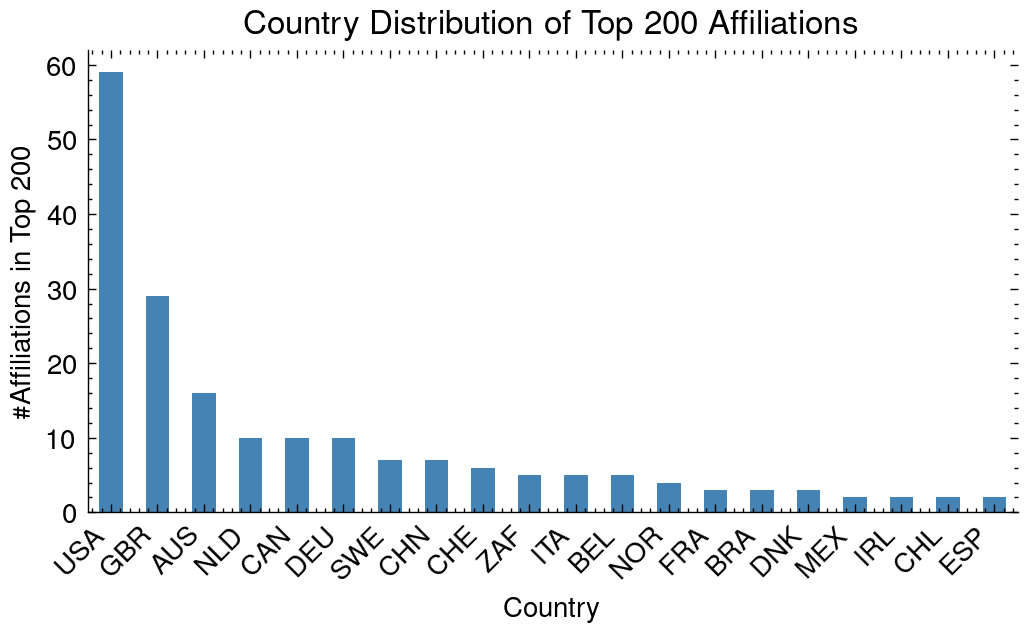


Country distribution (Top 20):
country
USA    59
GBR    29
AUS    16
NLD    10
CAN    10
DEU    10
SWE     7
CHN     7
CHE     6
ZAF     5
ITA     5
BEL     5
NOR     4
FRA     3
BRA     3
DNK     3
MEX     2
IRL     2
CHL     2
ESP     2
Name: count, dtype: int64


In [12]:

import matplotlib.pyplot as plt

plt.style.use(['science'])

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.spines.right": False,
    "axes.spines.top": False,
})

plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""

fig, ax = plt.subplots(figsize=(6, 3))

country_counts = count_af.iloc[:200]['country'].value_counts()[:20]
country_counts.plot.bar(ax=ax, color='#4583B5')

ax.set_xlabel('Country')
ax.set_ylabel(r'\texttt{\#}Affiliations in Top 200')
ax.set_title('Country Distribution of Top 200 Affiliations')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f"\nCountry distribution (Top 20):")
print(country_counts)